## Generate Specta

In [1]:
# === CELDA 1 ===
from __future__ import annotations

import os
from typing import Tuple, Optional, Dict

import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

# Paths (edit if needed)
MODEL_PATH = "Models/AE_l2_05.keras"
OBS_DIR = "observations"
CLEAN_PATH = "pandexo_spec.txt"

# ====== UQ helpers & const (NUEVO) ======
EPS_RANGE = 1e-12  # traza "plana" si el rango ~ 0

def _min_max_stats_1d(arr: np.ndarray, dtype=np.float32):
    arr = np.asarray(arr, dtype=dtype)
    amin = float(np.min(arr))
    amax = float(np.max(arr))
    rng  = amax - amin
    return amin, amax, rng

def mc_ale_1d_anchor_clean(
    autoencoder,
    y_noisy: np.ndarray,          # (D,)
    clean_ref: np.ndarray,        # (D,)
    sigma: float | np.ndarray,    # escalar o (D,)
    n_repeat: int = 100,
    dtype=np.float32,
) -> tuple[np.ndarray, np.ndarray]:
    """
    σ_ale para una sola traza:
    - Perturba y_noisy con N(0, sigma)
    - Normaliza per-réplica con su propio min/max
    - Forward (training=False)
    - Des-normaliza con min/max del CLEAN
    """
    y_noisy = np.asarray(y_noisy, dtype=dtype)
    clean_ref = np.asarray(clean_ref, dtype=dtype)
    D = y_noisy.size
    if clean_ref.size != D:
        raise ValueError("clean_ref y y_noisy deben tener misma longitud.")

    cmin, cmax, crng = _min_max_stats_1d(clean_ref, dtype=dtype)
    deg_clean = (crng <= EPS_RANGE)
    crng_safe = crng if crng > 0.0 else 1.0

    # Ruido
    if np.ndim(sigma) == 0:
        noise = np.random.standard_normal(size=(n_repeat, D)).astype(dtype) * float(sigma)
    else:
        sigma_vec = np.asarray(sigma, dtype=dtype)
        if sigma_vec.shape != (D,):
            raise ValueError("sigma debe ser escalar o de forma (D,).")
        noise = np.random.standard_normal(size=(n_repeat, D)).astype(dtype) * sigma_vec[None, :]

    reps = y_noisy[None, :] + noise  # (R, D)
    del noise

    # Normalización por réplica
    reps_min = reps.min(axis=1, keepdims=True)  # (R,1)
    reps_max = reps.max(axis=1, keepdims=True)
    reps_rng = (reps_max - reps_min).astype(dtype)
    reps_rng_safe = np.where(reps_rng <= 0.0, 1.0, reps_rng)
    reps_norm = (reps - reps_min) / reps_rng_safe
    # Si la réplica es plana -> zeros
    flat = (reps_rng[:, 0] <= EPS_RANGE)
    if np.any(flat):
        reps_norm[flat] = 0.0

    # Forward
    preds_norm = []
    for i in range(reps_norm.shape[0]):
        y = autoencoder(reps_norm[i][None, :], training=False).numpy()[0].astype(dtype, copy=False)
        preds_norm.append(y)
    preds_norm = np.asarray(preds_norm, dtype=dtype)  # (R, D)

    # Des-norm con CLEAN
    preds = preds_norm * crng_safe + cmin
    if deg_clean:
        preds[:] = cmin  # constante si el CLEAN era plano
    recon_mean = preds.mean(axis=0)
    sigma_ale  = preds.std(axis=0, ddof=1)
    return recon_mean.astype(dtype), sigma_ale.astype(dtype)

def mc_dropout_1d_anchor_clean(
    autoencoder,
    y_noisy: np.ndarray,       # (D,)
    clean_ref: np.ndarray,     # (D,)
    t_passes: int = 100,
    dtype=np.float32,
) -> tuple[np.ndarray, np.ndarray]:
    """
    σ_epi para una sola traza:
    - Normaliza con min/max del NOISY
    - Forward T veces con training=True (Dropout activo)
    - Des-normaliza con min/max del CLEAN
    """
    y_noisy = np.asarray(y_noisy, dtype=dtype)
    clean_ref = np.asarray(clean_ref, dtype=dtype)
    D = y_noisy.size
    if clean_ref.size != D:
        raise ValueError("clean_ref y y_noisy deben tener misma longitud.")

    # NOISY stats (para normalizar la entrada)
    xmin, xmax, xrng = _min_max_stats_1d(y_noisy, dtype=dtype)
    xrng_safe = xrng if xrng > 0.0 else 1.0
    x_norm = (y_noisy - xmin) / xrng_safe
    if xrng <= EPS_RANGE:
        x_norm[:] = 0.0

    # CLEAN stats (para des-normalizar la salida)
    cmin, cmax, crng = _min_max_stats_1d(clean_ref, dtype=dtype)
    crng_safe = crng if crng > 0.0 else 1.0
    deg_clean = (crng <= EPS_RANGE)

    outs_norm = []
    for _ in range(int(t_passes)):
        y = autoencoder(x_norm[None, :], training=True).numpy()[0].astype(dtype, copy=False)
        outs_norm.append(y)
    outs_norm = np.asarray(outs_norm, dtype=dtype)  # (T, D)

    outs = outs_norm * crng_safe + cmin
    if deg_clean:
        outs[:] = cmin

    mean_dropout = outs.mean(axis=0).astype(dtype)
    sigma_epi    = outs.std(axis=0, ddof=1).astype(dtype)
    return mean_dropout, sigma_epi

def combine_uncertainties_1d(
    sigma_ale: np.ndarray,
    sigma_epi: Optional[np.ndarray] = None,
    sigma_sys: Optional[np.ndarray] = None,
    floor: float = 0.0,
    dtype=np.float32,
) -> np.ndarray:
    sig2 = np.asarray(sigma_ale, dtype=dtype) ** 2
    if sigma_epi is not None:
        sig2 += np.asarray(sigma_epi, dtype=dtype) ** 2
    if sigma_sys is not None:
        sig2 += np.asarray(sigma_sys, dtype=dtype) ** 2
    sigma_total = np.sqrt(sig2).astype(dtype, copy=False)
    if floor > 0.0:
        sigma_total = np.maximum(sigma_total, floor).astype(dtype, copy=False)
    return sigma_total


In [2]:
# === CELDA 2 ===
def bin_average_with_halfbins(
    wl_src: np.ndarray,
    y_src: np.ndarray,
    centers: np.ndarray,
    halfwidths: np.ndarray,
    nsamp: int = 256,
) -> np.ndarray:
    """
    Band-average y_src over each band [c - h, c + h] using trapezoidal
    integration of a linear 1D interpolation over wl_src.
    """
    wl_src = np.asarray(wl_src, dtype=np.float64)
    y_src = np.asarray(y_src, dtype=np.float64)
    centers = np.asarray(centers, dtype=np.float64)
    halfwidths = np.asarray(halfwidths, dtype=np.float64)

    sort_idx = np.argsort(wl_src)
    wl_s = wl_src[sort_idx]
    y_s = y_src[sort_idx]

    out = np.empty_like(centers, dtype=np.float64)
    for i, (c, h) in enumerate(zip(centers, halfwidths)):
        a, b = c - h, c + h
        x = np.linspace(a, b, nsamp)
        yx = np.interp(x, wl_s, y_s)  # clipped extrapolation at the edges
        out[i] = np.trapz(yx, x) / (b - a)
    return out.astype(np.float32)


In [3]:
# === CELDA 3 ===
def normalize_min_max(arr: np.ndarray) -> np.ndarray:
    """
    Apply sample-wise Min–Max normalization to a 1D array.
    If the range is zero, returns an array of zeros.
    """
    arr = np.asarray(arr, dtype=np.float32)
    min_val = float(arr.min())
    max_val = float(arr.max())
    rng = max_val - min_val
    if rng == 0.0:
        return np.zeros_like(arr)
    return (arr - min_val) / rng


def inverse_min_max_1d(normed: np.ndarray, ref: np.ndarray) -> np.ndarray:
    """
    Invert Min–Max normalization for a 1D array using a reference array.
    real = normed * (max_ref - min_ref) + min_ref
    """
    normed = np.asarray(normed, dtype=np.float32)
    min_ref = float(np.min(ref))
    max_ref = float(np.max(ref))
    return normed * (max_ref - min_ref) + min_ref


In [4]:
# === CELDA 4 ===
def load_spectrum(spec_name: str, obs_dir: str = OBS_DIR) -> np.ndarray:
    """
    Load an observation file as an Nx4 array: (wl, Δwl, rp2/rs2, err).
    """
    path = os.path.join(obs_dir, f"{spec_name}.dat")
    if not os.path.isfile(path):
        raise FileNotFoundError(f"Observation not found: {path}")
    arr = np.loadtxt(path)
    if arr.ndim != 2 or arr.shape[1] < 4:
        raise ValueError(f"Expected (N, 4)+ columns, got shape {arr.shape}")
    return arr[:, :4].astype(np.float32)


def split_spectrum_columns(
    spectrum: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Split spectrum columns into typed vectors: (wl, Δwl, noisy, err).
    """
    wl = spectrum[:, 0].astype(np.float32)
    d_wl = spectrum[:, 1].astype(np.float32)
    y_noisy = spectrum[:, 2].astype(np.float32)
    y_err = spectrum[:, 3].astype(np.float32)
    return wl, d_wl, y_noisy, y_err


def load_clean_spectrum(clean_path: str = CLEAN_PATH) -> Tuple[np.ndarray, np.ndarray]:
    """
    Load the clean spectrum with two columns: (wl, depth).
    """
    if not os.path.isfile(clean_path):
        raise FileNotFoundError(f"Clean spectrum not found: {clean_path}")
    arr = np.loadtxt(clean_path)
    if arr.ndim != 2 or arr.shape[1] < 2:
        raise ValueError(
            f"Expected at least 2 columns in clean spectrum, got {arr.shape}"
        )
    return arr[:, 0].astype(np.float32), arr[:, 1].astype(np.float32)


In [5]:
# === CELDA 5 ===
def force_reverse_order(
    wl: np.ndarray,
    d_wl: np.ndarray,
    y_noisy: np.ndarray,
    y_err: np.ndarray,
    y_clean_binned: np.ndarray,
):
    """
    Force a strict reverse of all input vectors along axis 0.
    """
    return (
        wl[::-1].copy(),
        d_wl[::-1].copy(),
        y_noisy[::-1].copy(),
        y_err[::-1].copy(),
        y_clean_binned[::-1].copy(),
    )


In [6]:
# === CELDA 6 ===
def load_autoencoder(model_path: str = MODEL_PATH):
    """
    Load a Keras autoencoder from disk.
    """
    return keras.models.load_model(model_path)


In [7]:
# === CELDA 7 (MODIFICADA) ===
def reconstruct_trace(
    autoencoder,
    y_noisy: np.ndarray,
    clean_ref: np.ndarray,
) -> np.ndarray:
    """
    Reconstrucción directa (sin UQ). Conservada por compatibilidad.
    """
    n_features = int(autoencoder.input_shape[-1])
    if len(y_noisy) != n_features or len(clean_ref) != n_features:
        raise AssertionError(
            f"Model expects length {n_features}; got "
            f"{len(y_noisy)} (noisy), {len(clean_ref)} (clean)."
        )

    x_norm = normalize_min_max(y_noisy)
    x_in = x_norm.reshape(1, -1).astype(np.float32)  # (1, n_features)
    y_pred_norm = autoencoder.predict(x_in, verbose=0)[0]  # (n_features,)
    y_recon = inverse_min_max_1d(y_pred_norm, clean_ref)
    return y_recon.astype(np.float32)


def reconstruct_trace_with_uq(
    autoencoder,
    y_noisy: np.ndarray,
    clean_ref: np.ndarray,
    sigma_inst: np.ndarray | float,
    monte_carlo_repeats: int = 100, # Ya no se usa para aleatoria, pero se deja para no romper firmas
    t_passes_dropout: int = 100,
    eps_sigma_floor: float = 0.0,
    dtype=np.float32,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Reconstruye una traza y calcula UQ.
    CAMBIO: sigma_ale es ahora 0.5 * sigma_inst (sin Monte Carlo).
    sigma_epi sigue siendo calculado via MC Dropout.
    """
    
    # --- 1. Calcular Sigma Aleatoria Directamente ---
    # Reemplazamos la llamada a mc_ale_1d_anchor_clean por cálculo directo
    # Aseguramos que sea array y del tipo correcto
    sigma_ale = 0.5 * np.asarray(sigma_inst, dtype=dtype)
    
    # Si sigma_inst es escalar, lo convertimos a vector para consistencia (opcional pero seguro)
    if sigma_ale.ndim == 0:
        sigma_ale = np.full_like(y_noisy, sigma_ale, dtype=dtype)

    # --- 2. Recon + Sigma Epistémica (MC Dropout) ---
    # Esto se mantiene igual para obtener la media de predicción y la incertidumbre del modelo
    mean_dropout, sigma_epi = mc_dropout_1d_anchor_clean(
        autoencoder=autoencoder,
        y_noisy=y_noisy,
        clean_ref=clean_ref,
        t_passes=t_passes_dropout,
        dtype=dtype,
    )

    # --- 3. Combinar incertidumbres ---
    sigma_total = combine_uncertainties_1d(
        sigma_ale=sigma_ale,
        sigma_epi=sigma_epi,
        floor=eps_sigma_floor,
        dtype=dtype,
    )
    
    return mean_dropout.astype(dtype), sigma_ale, sigma_epi, sigma_total

In [8]:
# === CELDA 8 ===
def save_reconstructed(
    spec_name: str,
    wl: np.ndarray,
    d_wl: np.ndarray,
    y_recon: np.ndarray,
    y_err_updated: np.ndarray,   # ahora debe ser σ_total
    obs_dir: str = OBS_DIR,
) -> str:
    """
    Guarda 4 columnas: (wl, Δwl, recon, err_actualizada) dentro de `obs_dir`.
    """
    out = np.column_stack((wl, d_wl, y_recon, y_err_updated))
    out_path = os.path.join(obs_dir, f"{spec_name}_recon.dat")
    np.savetxt(out_path, out, fmt="%.10e")
    return out_path


In [10]:
# === DEFINICIÓN DE LA FUNCIÓN COORDINADORA ===

def reconstruct_and_save(
    spec_name: str,
    model_path: str,
    obs_dir: str,
    clean_path: str,
    nsamp: int = 256,
    show_plot: bool = True,
) -> str:
    """
    Función 'pegamento' que:
    1. Carga datos.
    2. Procesa (binned, reverse).
    3. Reconstruye usando tu CELDA 7 MODIFICADA.
    4. Guarda usando tu CELDA 8.
    5. Grafica resultados.
    """
    
    # --- 1. CARGAR ---
    autoencoder = load_autoencoder(model_path)
    # Cargar espectro ruidoso
    spec_data = load_spectrum(spec_name, obs_dir=obs_dir)
    wl, d_wl, y_noisy, y_err = split_spectrum_columns(spec_data)
    
    # Cargar referencia limpia
    wl_clean_hr, depth_clean_hr = load_clean_spectrum(clean_path=clean_path)

    # --- 2. PROCESAR (Binning + Reverse) ---
    # Binning del clean para comparar
    y_clean_binned = bin_average_with_halfbins(
        wl_src=wl_clean_hr, 
        y_src=depth_clean_hr, 
        centers=wl, 
        halfwidths=d_wl, 
        nsamp=nsamp
    )

    # Forzar orden (crucial para que coincida con el entrenamiento)
    wl, d_wl, y_noisy, y_err, y_clean_binned = force_reverse_order(
        wl, d_wl, y_noisy, y_err, y_clean_binned
    )

    # --- 3. RECONSTRUCCIÓN CON UQ (Usa tu Celda 7) ---
    # Pasamos y_err como sigma_inst. Tu Celda 7 calculará: sigma_ale = 0.5 * y_err
    mu_pred, sig_ale, sig_epi, sig_tot = reconstruct_trace_with_uq(
        autoencoder=autoencoder,
        y_noisy=y_noisy,
        clean_ref=y_clean_binned,
        sigma_inst=y_err,         
        monte_carlo_repeats=100,  # No afecta aleatoria, pero necesario por sintaxis
        t_passes_dropout=100
    )

    # --- 4. GUARDAR (Usa tu Celda 8) ---
    # Guardamos la reconstrucción y la incertidumbre TOTAL nueva
    out_path = save_reconstructed(
        spec_name=spec_name,
        wl=wl,
        d_wl=d_wl,
        y_recon=mu_pred,
        y_err_updated=sig_tot, # Guardamos sigma total como el nuevo error
        obs_dir=obs_dir
    )

    # --- 5. GRAFICAR ---
    if show_plot:
        plt.figure(figsize=(10, 5))
        plt.title(f"Reconstruction: {spec_name}")
        
        # Datos originales
        plt.errorbar(wl, y_noisy, yerr=y_err, fmt='.', color='gray', alpha=0.3, label='Observed (Noisy)')
        plt.plot(wl, y_clean_binned, 'k--', lw=1, alpha=0.7, label='Clean Reference')
        
        # Reconstrucción
        plt.plot(wl, mu_pred, 'r-', lw=2, label='Reconstruction')
        
        # Sombra de incertidumbre total (Epistémica + Aleatoria fija)
        plt.fill_between(wl, mu_pred - sig_tot, mu_pred + sig_tot, 
                         color='red', alpha=0.2, label='Total Uncertainty')

        plt.xlabel("Wavelength (um)")
        plt.ylabel("Depth")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return out_path

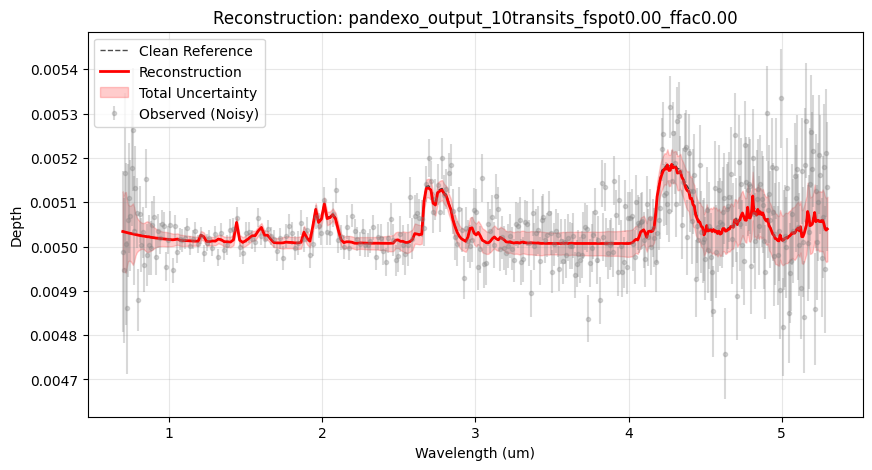

Saved: observations\pandexo_output_10transits_fspot0.00_ffac0.00_recon.dat


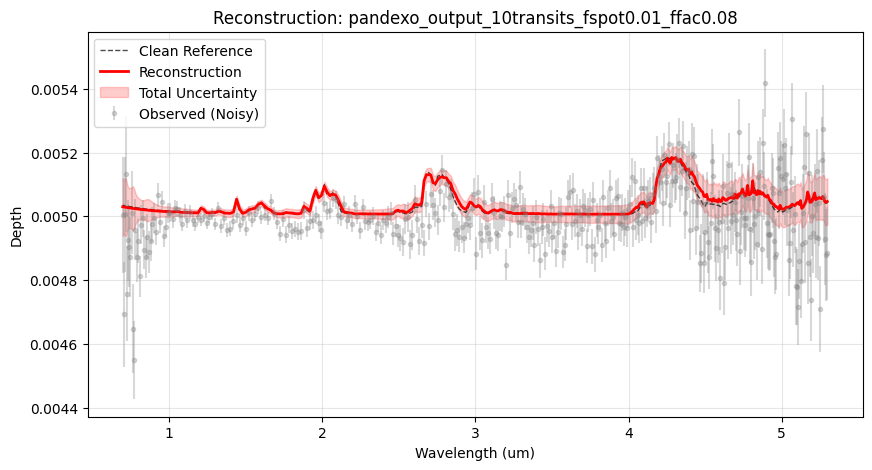

Saved: observations\pandexo_output_10transits_fspot0.01_ffac0.08_recon.dat


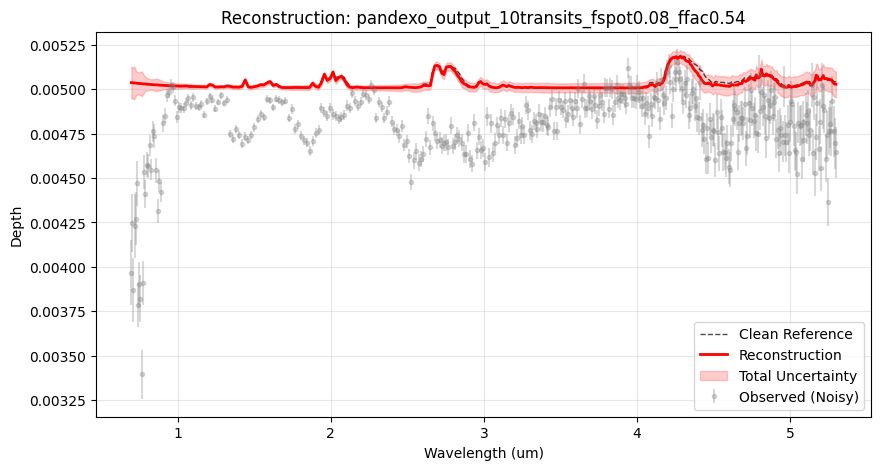

Saved: observations\pandexo_output_10transits_fspot0.08_ffac0.54_recon.dat


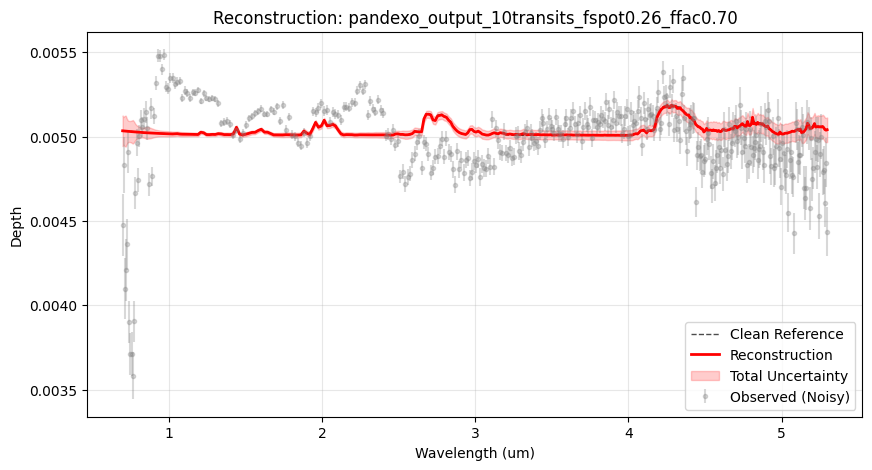

Saved: observations\pandexo_output_10transits_fspot0.26_ffac0.70_recon.dat


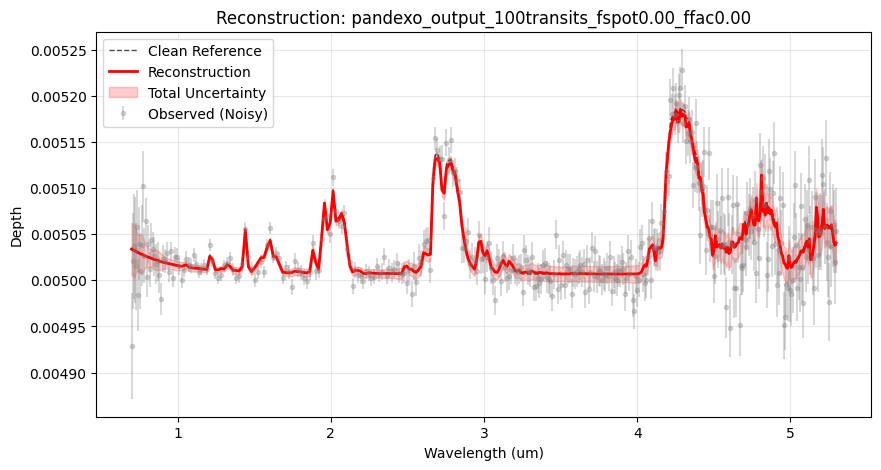

Saved: observations\pandexo_output_100transits_fspot0.00_ffac0.00_recon.dat


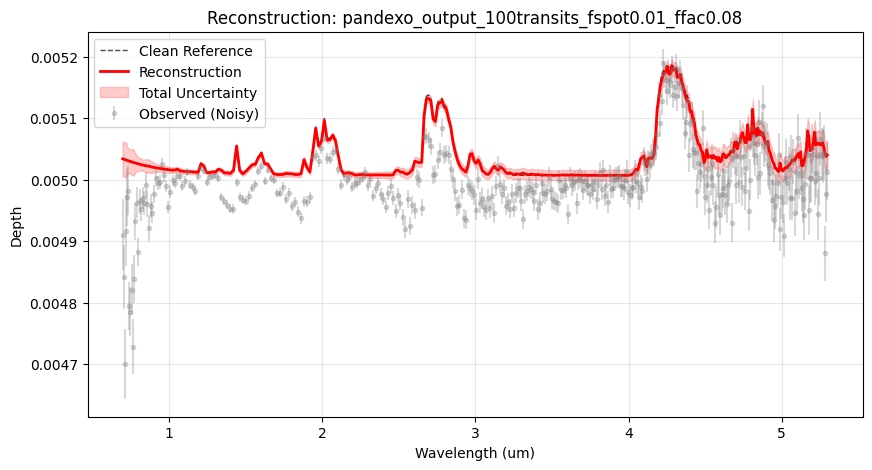

Saved: observations\pandexo_output_100transits_fspot0.01_ffac0.08_recon.dat


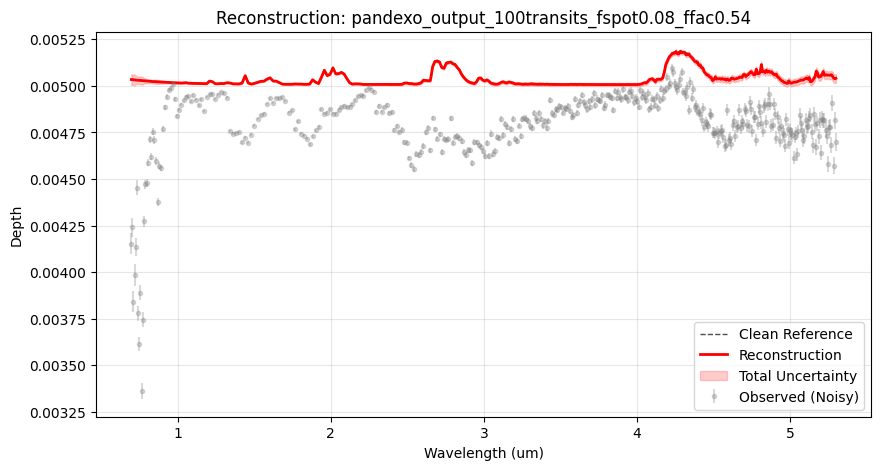

Saved: observations\pandexo_output_100transits_fspot0.08_ffac0.54_recon.dat


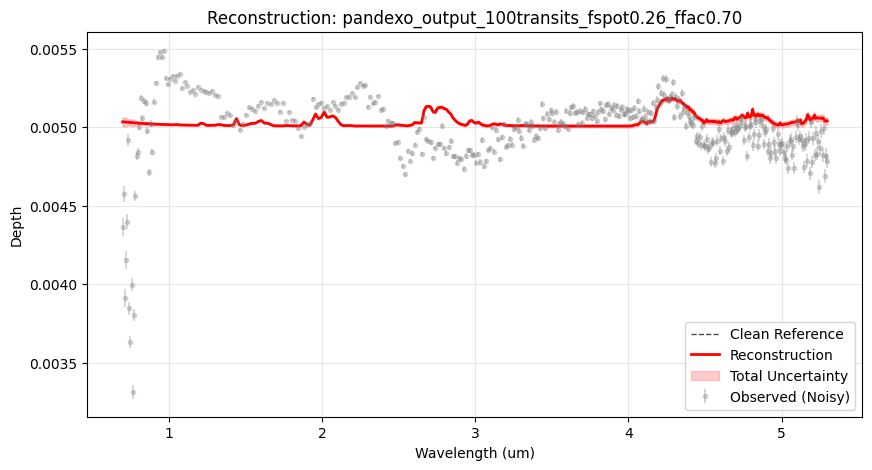

Saved: observations\pandexo_output_100transits_fspot0.26_ffac0.70_recon.dat


In [11]:
# Set the spectrum base name (without .dat)
specs_name = ["pandexo_output_10transits_fspot0.00_ffac0.00",
              "pandexo_output_10transits_fspot0.01_ffac0.08",
              "pandexo_output_10transits_fspot0.08_ffac0.54",
              "pandexo_output_10transits_fspot0.26_ffac0.70",
              "pandexo_output_100transits_fspot0.00_ffac0.00",
              "pandexo_output_100transits_fspot0.01_ffac0.08",
              "pandexo_output_100transits_fspot0.08_ffac0.54",
              "pandexo_output_100transits_fspot0.26_ffac0.70",
]


for spec_name in specs_name:
    out_path = reconstruct_and_save(
        spec_name=spec_name,
        model_path=MODEL_PATH,
        obs_dir=OBS_DIR,
        clean_path=CLEAN_PATH,
        nsamp=256,
        show_plot=True,   # set False to skip plotting
    )

    print(f"Saved: {out_path}")


## POSEIDON RETRIEVAL

In [1]:
from POSEIDON.core import create_star
from POSEIDON.core import  create_planet
from POSEIDON.constants import R_Sun, R_E, M_E
import numpy as np



#***** Define stellar properties *****#

R_s =  0.1192 * R_Sun    # Stellar radius (m)
T_s = 2566.0          # Stellar effective temperature (K)
Met_s = 0.00         # Stellar metallicity [log10(Fe/H_star / Fe/H_solar)]
log_g_s = 5.2396

# Create the stellar object



star = create_star(R_s, T_s, log_g_s, Met_s,
                   stellar_grid= "phoenix",
                   )


                   #***** Define planet properties *****#

planet_name = 'Trappist-1e'
R_p = 0.917985*R_E     # Planetary radius (m)
M_p = 0.6356*M_E       # Planetary mass (kg)
T_eq = 255.0           # Equilibrium temperature (K)

# Create the planet object
planet = create_planet(planet_name, R_p, mass = M_p, T_eq = T_eq)

/home/dasan/anaconda3/envs/POSEIDON/lib/python3.10/site-packages/pysynphot/__init__.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


AttributeError: 'Legend' object has no attribute 'legend_handles'

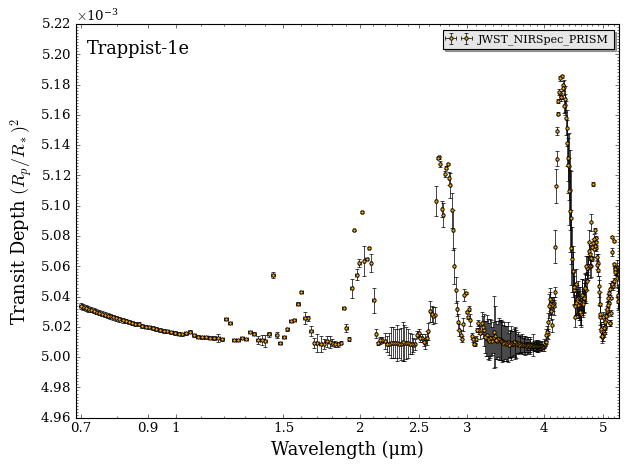

In [3]:
from POSEIDON.core import load_data, wl_grid_constant_R
from POSEIDON.visuals import plot_data



observation = 'pandexo_output_10transits_fspot0.26_ffac0.70_recon.dat'
#***** Model wavelength grid *****#

wl_min = 0.4      # Minimum wavelength (um)
wl_max = 6.0      # Maximum wavelength (um)
R = 4000         # Spectral resolution of grid

# We need to provide a model wavelength grid to initialise instrument properties
wl = wl_grid_constant_R(wl_min, wl_max, R)

#***** Specify data location and instruments  *****#

data_dir = 'observations'         # Change this to where your data is stored
datasets = [observation]  # Found in reference_data/observations
instruments = ['JWST_NIRSpec_PRISM']             # Instruments corresponding to the data

# Load dataset, pre-load instrument PSF and transmission function
data = load_data(data_dir, datasets, instruments, wl)


# Plot our data
fig_data = plot_data(data, planet_name)

In [106]:
from POSEIDON.core import define_model

#***** Define model *****#
model_name = 'recon_100T_0.26spot-0.70fac'  # Model name used for plots, output files etc.

bulk_species = ['N2']      # H2 + He comprises the bulk atmosphere
param_species = ['H2O', 'CH4', 'CO2', "O3"]   # The trace gases are H2O and CH4

# Create the model object
model = define_model(model_name, bulk_species, param_species,
                     PT_profile = 'isotherm', cloud_model = 'cloud-free',
                     )

# Check the free parameters defining this model
print("Free parameters: " + str(model['param_names']))

Free parameters: ['R_p_ref' 'T' 'log_H2O' 'log_CH4' 'log_CO2' 'log_O3']


In [108]:
from POSEIDON.core import set_priors

#***** Set priors for retrieval *****#

# Initialise prior type dictionary
prior_types = {}

# Specify whether priors are linear, Gaussian, etc.
prior_types['T'] = 'uniform'
prior_types['R_p_ref'] = 'uniform'
prior_types['log_H2O'] = 'uniform'
#'log_H2O' 'log_CH4' 'log_CO2' 'log_O3'
prior_types['log_CH4'] = 'uniform'
prior_types['log_CO2'] = 'uniform'
prior_types['log_O3'] = 'uniform'



# Initialise prior range dictionary
prior_ranges = {}

# Specify prior ranges for each free parameter
prior_ranges['T'] = [200, 400]
prior_ranges['R_p_ref'] = [0.85*R_p, 1.15*R_p]
prior_ranges['log_H2O'] = [-8, -1]
prior_ranges['log_CH4'] = [-8, -1]
prior_ranges['log_CO2'] = [-5, -1]
prior_ranges['log_O3'] = [-8, -1]

# Create prior object for retrieval
priors = set_priors(planet, star, model, data, prior_types, prior_ranges)

In [10]:
# === CELDA 10 ===
def reconstruct_and_save(
    spec_name: str,
    model_path: str = MODEL_PATH,
    obs_dir: str = OBS_DIR,
    clean_path: str = CLEAN_PATH,
    nsamp: int = 256,
    show_plot: bool = False,
    # Parámetros UQ:
    monte_carlo_repeats: int = 100,
    t_passes_dropout: int = 100,
    eps_sigma_floor: float = 0.0,
) -> str:
    """
    Pipeline E2E:
      1) Carga obs y CLEAN
      2) Binning del CLEAN a bandas de la obs
      3) Flip (si tu instrumento viene descendente)
      4) Recon AE + UQ (σ_ale, σ_epi, σ_total ancladas al CLEAN)
      5) Guarda (wl, Δwl, recon, σ_total)
    """
    # 1) Load observation and clean spectrum
    spectrum = load_spectrum(spec_name, obs_dir)
    wl, d_wl, y_noisy, y_err_inst = split_spectrum_columns(spectrum)
    wl_clean, y_clean = load_clean_spectrum(clean_path)

    # 2) Bin clean spectrum onto observation bands
    y_clean_binned = bin_average_with_halfbins(
        wl_src=wl_clean,
        y_src=y_clean,
        centers=wl,
        halfwidths=d_wl,
        nsamp=nsamp,
    )

    # 3) Forzar flip (tu caso conocido)
    wl, d_wl, y_noisy, y_err_inst, y_clean_binned = force_reverse_order(
        wl, d_wl, y_noisy, y_err_inst, y_clean_binned
    )

    # 4) Load model and reconstruct + UQ
    autoencoder = load_autoencoder(model_path)
    y_recon, sigma_ale, sigma_epi, sigma_total = reconstruct_trace_with_uq(
        autoencoder=autoencoder,
        y_noisy=y_noisy,
        clean_ref=y_clean_binned,
        sigma_inst=y_err_inst,                # usa errores observacionales como σ de entrada
        monte_carlo_repeats=monte_carlo_repeats,
        t_passes_dropout=t_passes_dropout,
        eps_sigma_floor=eps_sigma_floor,
        dtype=np.float32,
    )

    # 5) Save reconstructed file (err = σ_total)
    out_path = save_reconstructed(
        spec_name=spec_name,
        wl=wl,
        d_wl=d_wl,
        y_recon=y_recon,
        y_err_updated=sigma_total,
        obs_dir=obs_dir,
    )

    # 6) Optional quick-look
    if show_plot:
        plot_quicklook(
            y_noisy=y_noisy,
            y_recon=y_recon,
            y_clean=y_clean_binned,
            wl=wl,
            sigma_total=sigma_total,
        )

    return out_path


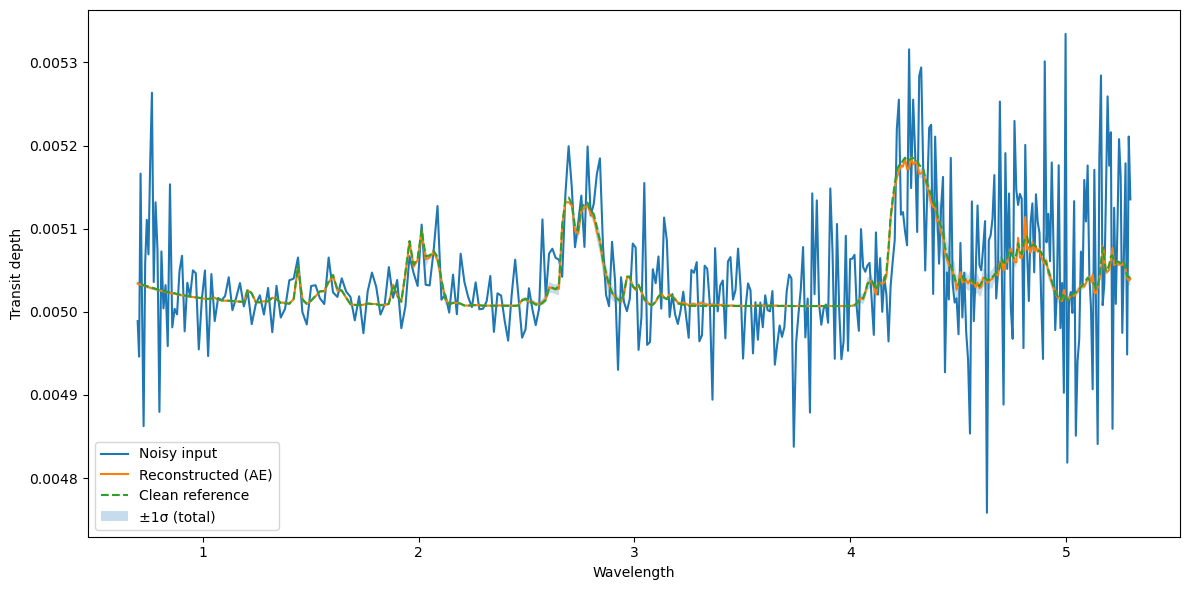

Saved: observations\pandexo_output_10transits_fspot0.00_ffac0.00_recon.dat


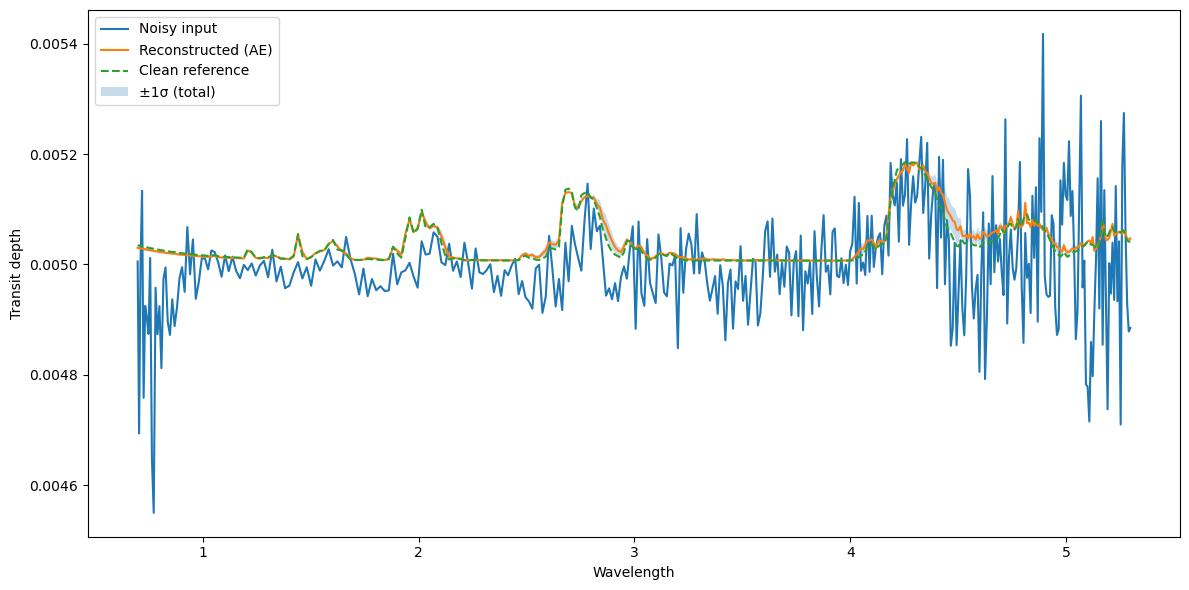

Saved: observations\pandexo_output_10transits_fspot0.01_ffac0.08_recon.dat


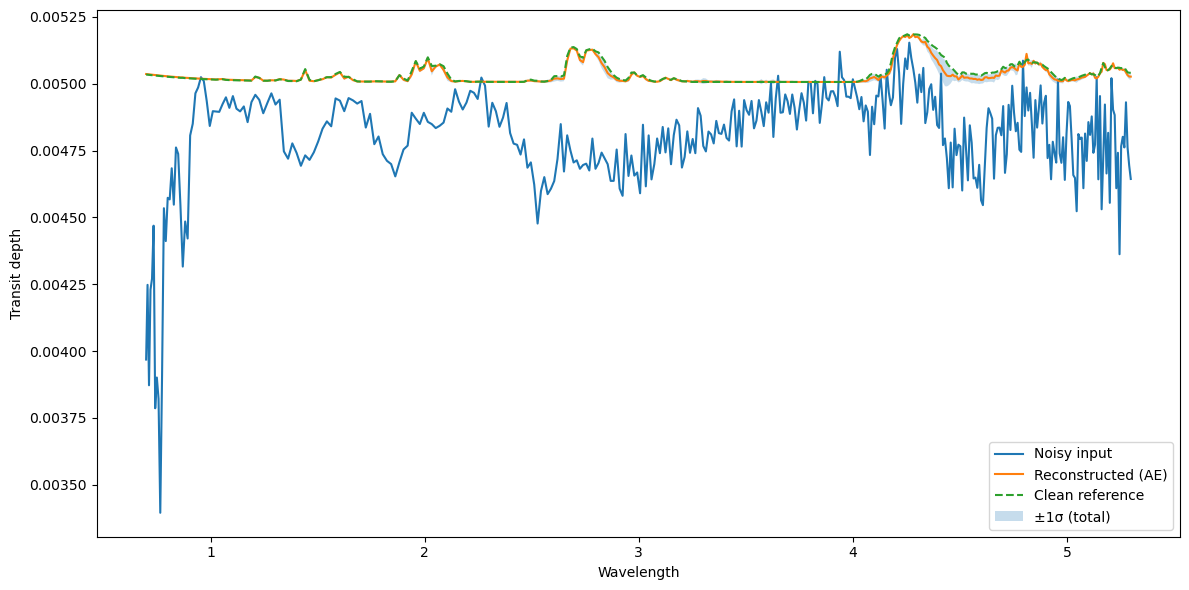

Saved: observations\pandexo_output_10transits_fspot0.08_ffac0.54_recon.dat


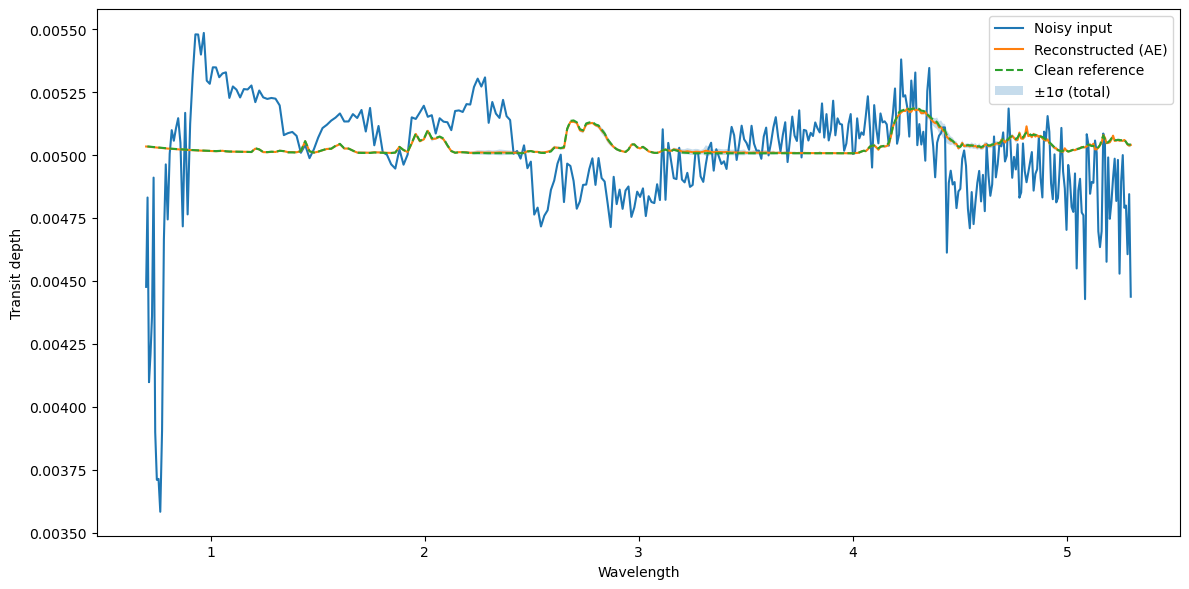

Saved: observations\pandexo_output_10transits_fspot0.26_ffac0.70_recon.dat


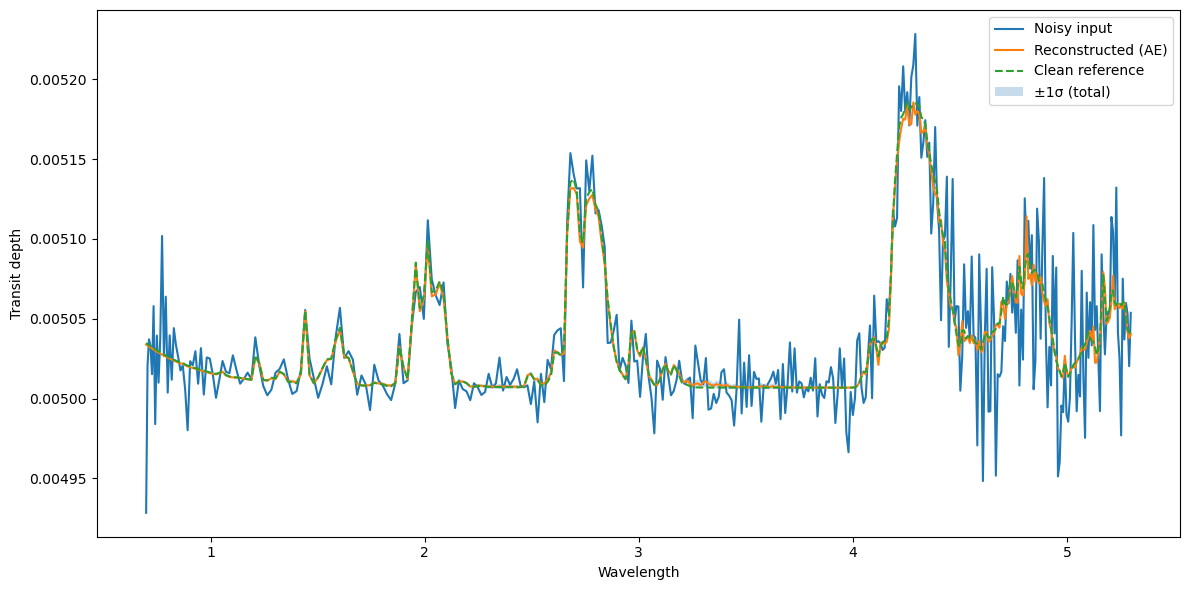

Saved: observations\pandexo_output_100transits_fspot0.00_ffac0.00_recon.dat


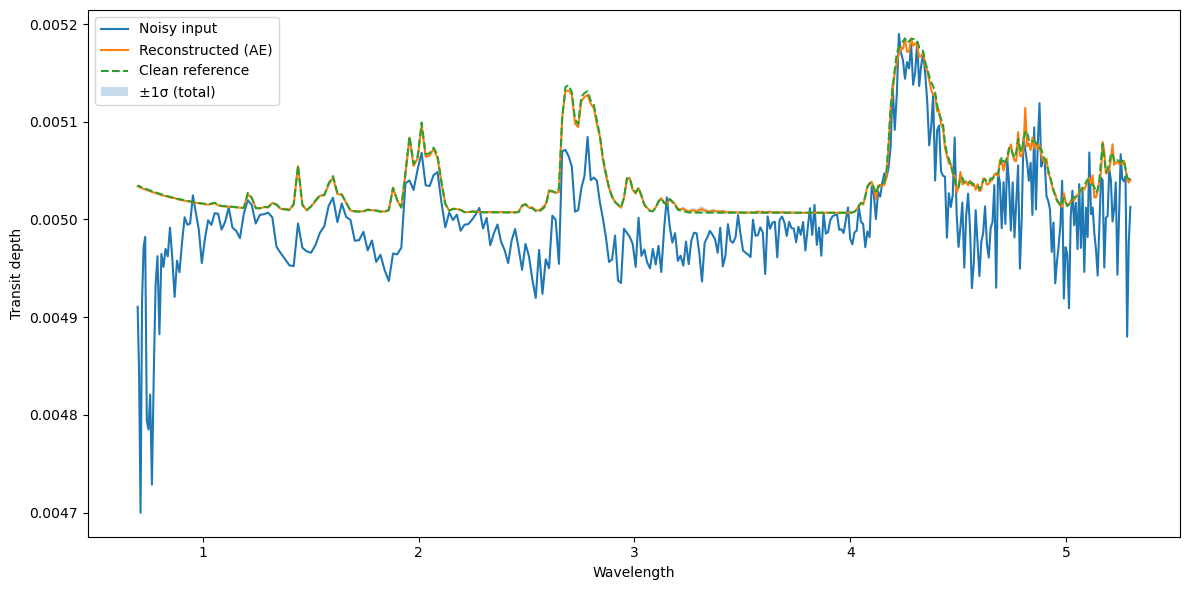

Saved: observations\pandexo_output_100transits_fspot0.01_ffac0.08_recon.dat


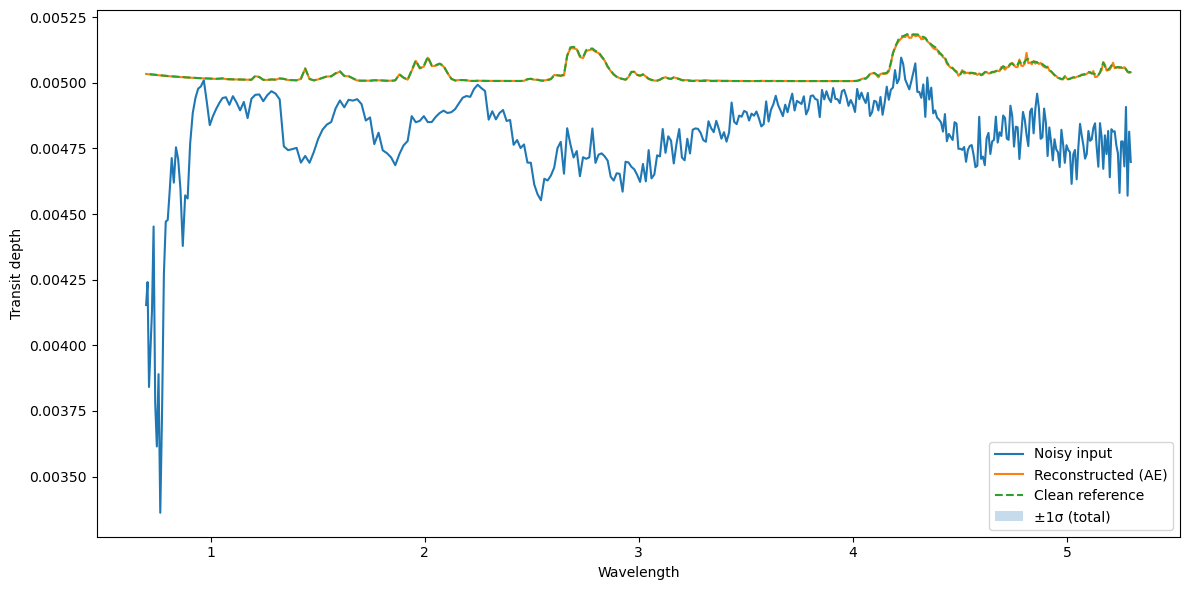

Saved: observations\pandexo_output_100transits_fspot0.08_ffac0.54_recon.dat


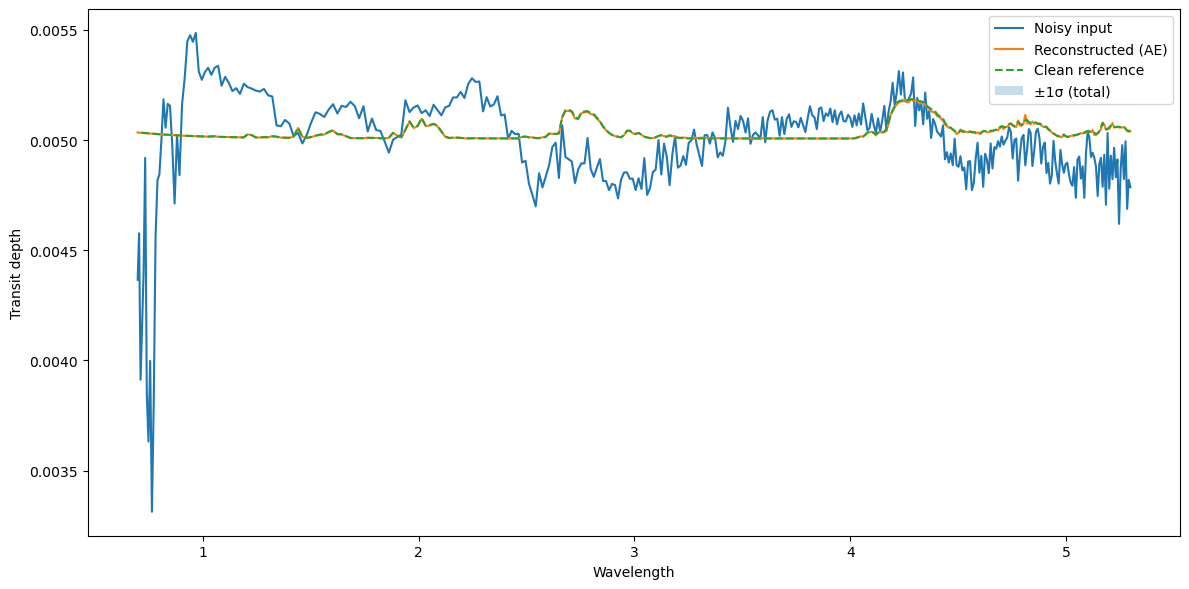

Saved: observations\pandexo_output_100transits_fspot0.26_ffac0.70_recon.dat


In [12]:
# === CELDA 11 ===
# Set the spectrum base name (without .dat)
specs_name = [
    "pandexo_output_10transits_fspot0.00_ffac0.00",
    "pandexo_output_10transits_fspot0.01_ffac0.08",
    "pandexo_output_10transits_fspot0.08_ffac0.54",
    "pandexo_output_10transits_fspot0.26_ffac0.70",
    "pandexo_output_100transits_fspot0.00_ffac0.00",
    "pandexo_output_100transits_fspot0.01_ffac0.08",
    "pandexo_output_100transits_fspot0.08_ffac0.54",
    "pandexo_output_100transits_fspot0.26_ffac0.70",
]

for spec_name in specs_name:
    out_path = reconstruct_and_save(
        spec_name=spec_name,
        model_path=MODEL_PATH,
        obs_dir=OBS_DIR,
        clean_path=CLEAN_PATH,
        nsamp=256,
        show_plot=True,   # set False to skip plotting
        # UQ params:
        monte_carlo_repeats=1000,   # ↑ si quieres σ_ale más estable
        t_passes_dropout=500,      # ↑ si quieres σ_epi más estable
        eps_sigma_floor=0.0,       # >0 si quieres un piso mínimo
    )

    print(f"Saved: {out_path}")


## POSEIDON RETRIEVAL

In [92]:
from POSEIDON.core import create_star
from POSEIDON.core import  create_planet
from POSEIDON.constants import R_Sun, R_E, M_E
import numpy as np



#***** Define stellar properties *****#

R_s =  0.1192 * R_Sun    # Stellar radius (m)
T_s = 2566.0          # Stellar effective temperature (K)
Met_s = 0.00         # Stellar metallicity [log10(Fe/H_star / Fe/H_solar)]
log_g_s = 5.2396

# Create the stellar object



star = create_star(R_s, T_s, log_g_s, Met_s,
                   stellar_grid= "phoenix",
                   )


                   #***** Define planet properties *****#

planet_name = 'Trappist-1e'
R_p = 0.917985*R_E     # Planetary radius (m)
M_p = 0.6356*M_E       # Planetary mass (kg)
T_eq = 255.0           # Equilibrium temperature (K)

# Create the planet object
planet = create_planet(planet_name, R_p, mass = M_p, T_eq = T_eq)

AttributeError: 'Legend' object has no attribute 'legend_handles'

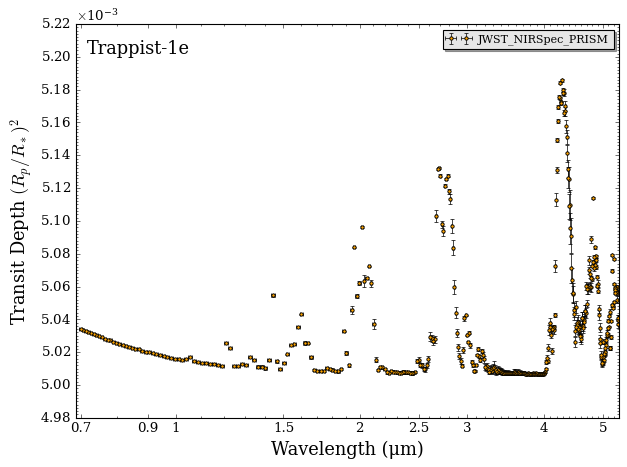

In [93]:
from POSEIDON.core import load_data, wl_grid_constant_R
from POSEIDON.visuals import plot_data



observation = 'pandexo_output_100transits_fspot0.26_ffac0.70_recon.dat'
#***** Model wavelength grid *****#

wl_min = 0.4      # Minimum wavelength (um)
wl_max = 6.0      # Maximum wavelength (um)
R = 4000         # Spectral resolution of grid

# We need to provide a model wavelength grid to initialise instrument properties
wl = wl_grid_constant_R(wl_min, wl_max, R)

#***** Specify data location and instruments  *****#

data_dir = 'observations'         # Change this to where your data is stored
datasets = [observation]  # Found in reference_data/observations
instruments = ['JWST_NIRSpec_PRISM']             # Instruments corresponding to the data

# Load dataset, pre-load instrument PSF and transmission function
data = load_data(data_dir, datasets, instruments, wl)


# Plot our data
fig_data = plot_data(data, planet_name)

In [94]:
from POSEIDON.core import define_model

#***** Define model *****#
model_name = 'recon_sigma_100T_0.26spot-0.70fac'  # Model name used for plots, output files etc.

bulk_species = ['N2']      # H2 + He comprises the bulk atmosphere
param_species = ['H2O', 'CH4', 'CO2', "O3"]   # The trace gases are H2O and CH4

# Create the model object
model = define_model(model_name, bulk_species, param_species,
                     PT_profile = 'isotherm', cloud_model = 'cloud-free',
                     )

# Check the free parameters defining this model
print("Free parameters: " + str(model['param_names']))

Free parameters: ['R_p_ref' 'T' 'log_H2O' 'log_CH4' 'log_CO2' 'log_O3']


In [95]:
from POSEIDON.core import set_priors

#***** Set priors for retrieval *****#

# Initialise prior type dictionary
prior_types = {}

# Specify whether priors are linear, Gaussian, etc.
prior_types['T'] = 'uniform'
prior_types['R_p_ref'] = 'uniform'
prior_types['log_H2O'] = 'uniform'
#'log_H2O' 'log_CH4' 'log_CO2' 'log_O3'
prior_types['log_CH4'] = 'uniform'
prior_types['log_CO2'] = 'uniform'
prior_types['log_O3'] = 'uniform'



# Initialise prior range dictionary
prior_ranges = {}

# Specify prior ranges for each free parameter
prior_ranges['T'] = [200, 400]
prior_ranges['R_p_ref'] = [0.85*R_p, 1.15*R_p]
prior_ranges['log_H2O'] = [-8, -1]
prior_ranges['log_CH4'] = [-8, -1]
prior_ranges['log_CO2'] = [-5, -1]
prior_ranges['log_O3'] = [-8, -1]

# Create prior object for retrieval
priors = set_priors(planet, star, model, data, prior_types, prior_ranges)

In [96]:
""" from POSEIDON.core import read_opacities
import numpy as np

#***** Read opacity data *****#

opacity_treatment = 'opacity_sampling'

# Define fine temperature grid (K)
T_fine_min = 200     # Same as prior range for T
T_fine_max = 400    # Same as prior range for T
T_fine_step = 10     # 10 K steps are a good tradeoff between accuracy and RAM

T_fine = np.arange(T_fine_min, (T_fine_max + T_fine_step), T_fine_step)

# Define fine pressure grid (log10(P/bar))
log_P_fine_min = -2   # 1 ubar is the lowest pressure in the opacity database
log_P_fine_max = 2    # 100 bar is the highest pressure in the opacity database
log_P_fine_step = 0.2   # 0.2 dex steps are a good tradeoff between accuracy and RAM

log_P_fine = np.arange(log_P_fine_min, (log_P_fine_max + log_P_fine_step),
                       log_P_fine_step)

# Pre-interpolate the opacities
opac = read_opacities(model, wl, opacity_treatment, T_fine, log_P_fine) """

" from POSEIDON.core import read_opacities\nimport numpy as np\n\n#***** Read opacity data *****#\n\nopacity_treatment = 'opacity_sampling'\n\n# Define fine temperature grid (K)\nT_fine_min = 200     # Same as prior range for T\nT_fine_max = 400    # Same as prior range for T\nT_fine_step = 10     # 10 K steps are a good tradeoff between accuracy and RAM\n\nT_fine = np.arange(T_fine_min, (T_fine_max + T_fine_step), T_fine_step)\n\n# Define fine pressure grid (log10(P/bar))\nlog_P_fine_min = -2   # 1 ubar is the lowest pressure in the opacity database\nlog_P_fine_max = 2    # 100 bar is the highest pressure in the opacity database\nlog_P_fine_step = 0.2   # 0.2 dex steps are a good tradeoff between accuracy and RAM\n\nlog_P_fine = np.arange(log_P_fine_min, (log_P_fine_max + log_P_fine_step),\n                       log_P_fine_step)\n\n# Pre-interpolate the opacities\nopac = read_opacities(model, wl, opacity_treatment, T_fine, log_P_fine) "

In [97]:
""" from POSEIDON.retrieval import run_retrieval

#***** Specify fixed atmospheric settings for retrieval *****#

# Atmospheric pressure grid
P_min = 1.0e-2    # 0.1 bar
P_max = 2       # 2 bar
N_layers = 100    # 100 layers

# Let's space the layers uniformly in log-pressure
P = np.logspace(np.log10(P_max), np.log10(P_min), N_layers)

# Specify the reference pressure
P_ref = 1.0   # Retrieved R_p_ref parameter will be the radius at 1 bar

#***** Run atmospheric retrieval *****#

run_retrieval(planet, star, model, opac, data, priors, wl, P, P_ref, R = R,
              spectrum_type = 'transmission', sampling_algorithm = 'MultiNest',
              N_live = 50, verbose = True) """

" from POSEIDON.retrieval import run_retrieval\n\n#***** Specify fixed atmospheric settings for retrieval *****#\n\n# Atmospheric pressure grid\nP_min = 1.0e-2    # 0.1 bar\nP_max = 2       # 2 bar\nN_layers = 100    # 100 layers\n\n# Let's space the layers uniformly in log-pressure\nP = np.logspace(np.log10(P_max), np.log10(P_min), N_layers)\n\n# Specify the reference pressure\nP_ref = 1.0   # Retrieved R_p_ref parameter will be the radius at 1 bar\n\n#***** Run atmospheric retrieval *****#\n\nrun_retrieval(planet, star, model, opac, data, priors, wl, P, P_ref, R = R,\n              spectrum_type = 'transmission', sampling_algorithm = 'MultiNest',\n              N_live = 50, verbose = True) "

Generating corner plot ...


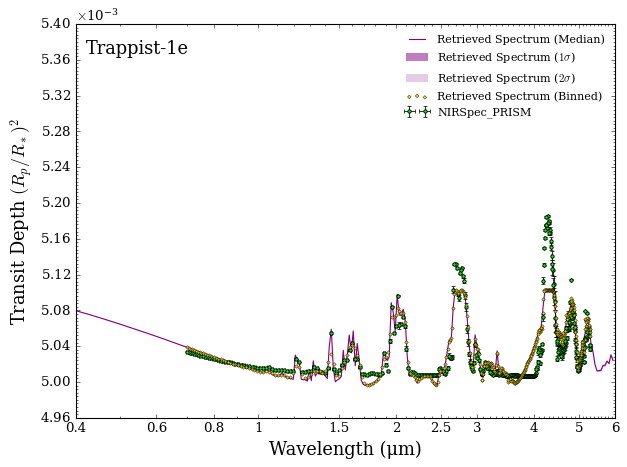

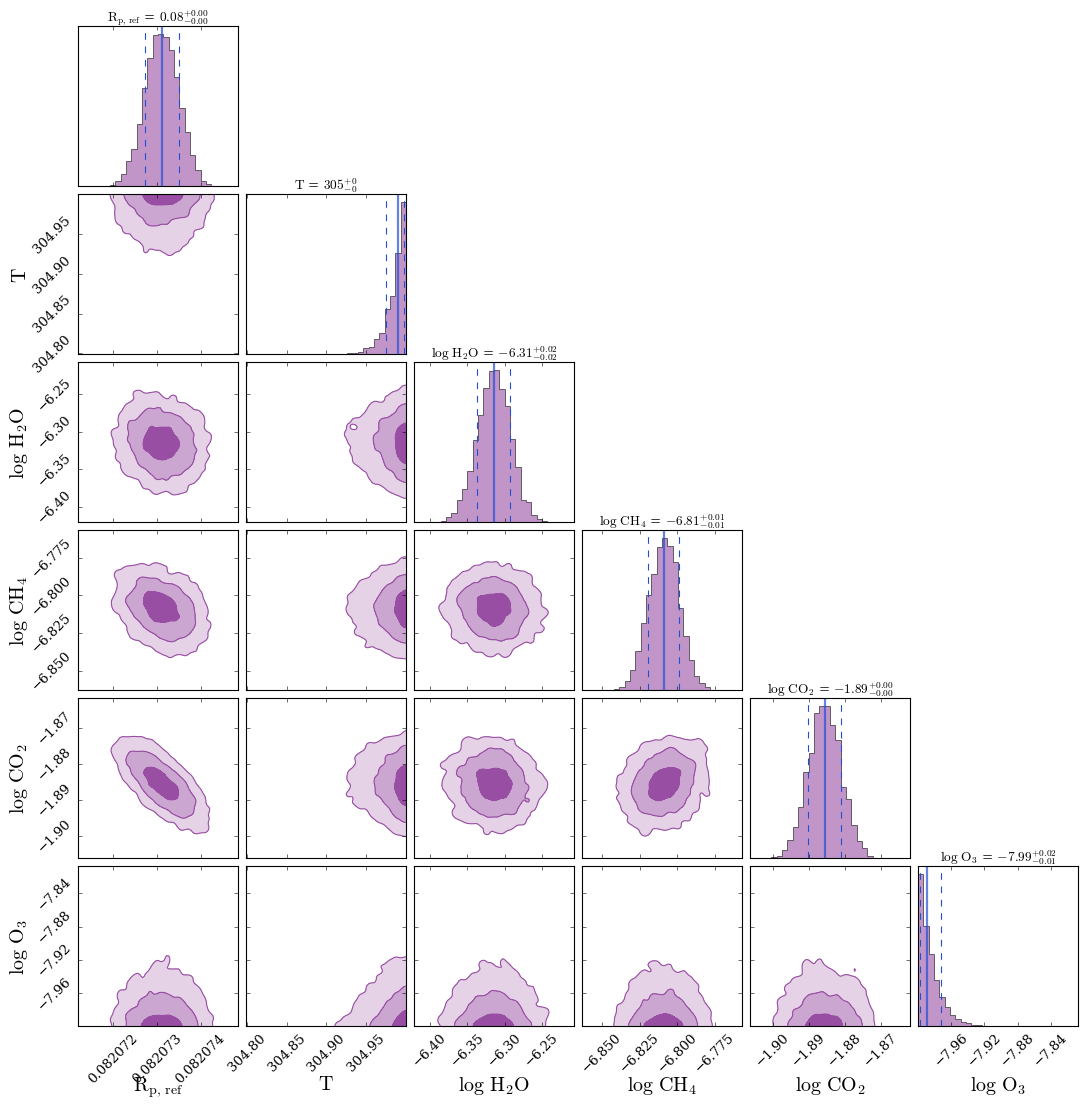

In [98]:
from POSEIDON.utility import read_retrieved_spectrum, plot_collection
from POSEIDON.visuals import plot_spectra_retrieved
from POSEIDON.corner import generate_cornerplot

#***** Plot retrieved transmission spectrum *****#

# Read retrieved spectrum confidence regions
wl, spec_low2, spec_low1, spec_median, \
spec_high1, spec_high2 = read_retrieved_spectrum(planet_name, model_name)

# Create composite spectra objects for plotting
spectra_median = plot_collection(spec_median, wl, collection = [])
spectra_low1 = plot_collection(spec_low1, wl, collection = [])
spectra_low2 = plot_collection(spec_low2, wl, collection = [])
spectra_high1 = plot_collection(spec_high1, wl, collection = [])
spectra_high2 = plot_collection(spec_high2, wl, collection = [])

# Produce figure
fig_spec = plot_spectra_retrieved(spectra_median, spectra_low2, spectra_low1,
                                  spectra_high1, spectra_high2, planet_name,
                                  data, R_to_bin = 100,
                                  data_labels = ['NIRSpec_PRISM'],
                                  data_colour_list = ['lime'])

#***** Make corner plot *****#

fig_corner = generate_cornerplot(planet, model)

True_flux = spec_median

In [99]:
n_free_params  = 11                        # Nº de parámetros libres del retrieval (ajústalo)
clean_path     = "pandexo_spec.txt"       # Archivo clean (wl_um, depth_clean)

In [100]:
# --- Celda 2: Imports y utilidades ---
import numpy as np
import pandas as pd

from POSEIDON.core import load_data
from POSEIDON.utility import read_retrieved_spectrum, read_data
from POSEIDON.instrument import bin_spectrum_to_data

def load_clean_two_cols(path):
    """
    Lee un archivo tipo 'wl  depth' (con espacios o tabs; ignora líneas con '#').
    Retorna wl_clean (um) y y_clean (profundidad), ordenados por wl.
    """
    arr = np.genfromtxt(path, comments="#", dtype=float)
    if arr.ndim == 1:
        arr = arr.reshape(-1, 1)
    if arr.shape[1] < 2:
        raise ValueError("Se esperaban ≥2 columnas (wl_um, depth_clean) en el clean file.")
    wl_clean = arr[:, 0].astype(float)
    y_clean  = arr[:, 1].astype(float)
    # Ordenar por longitud de onda por si acaso
    idx = np.argsort(wl_clean)
    return wl_clean[idx], y_clean[idx]

def bin_average_with_halfbins(wl_src, y_src, centers, halfwidths, nsamp=256):
    """
    Promedia y_src en cada banda [c-h, c+h] usando integración trapezoidal de
    una interpolación lineal sobre wl_src.
    """
    wl_src = np.asarray(wl_src); y_src = np.asarray(y_src)
    centers = np.asarray(centers); halfwidths = np.asarray(halfwidths)
    sort_idx = np.argsort(wl_src)
    wl_s = wl_src[sort_idx]; y_s = y_src[sort_idx]

    out = np.empty_like(centers, dtype=float)
    for i, (c, h) in enumerate(zip(centers, halfwidths)):
        a, b = c - h, c + h
        x = np.linspace(a, b, nsamp)
        # np.interp extrapola por los extremos con valores del borde (clipping)
        yx = np.interp(x, wl_s, y_s)
        out[i] = np.trapz(yx, x) / (b - a)
    return out


In [101]:
# --- Celda 3: Cargar clean truth y espectro recuperado ---
# Clean truth (pandexo_spec)
wl_clean, y_clean = load_clean_two_cols(clean_path)

# Espectro recuperado: devuelve wl_model y percentiles del espectro
wl_model, low2, low1, median, high1, high2 = read_retrieved_spectrum(planet_name, model_name)

# Cargar datos observados y pre-cargar instrument con la grilla del modelo
data = load_data(data_dir, [observation], instruments, wl_model)

# wl/anchos y datos+errores del archivo observado
wl_data, half_bin, y_obs, err_obs = read_data(data_dir, observation)

print(f"N puntos observación: {len(wl_data)}")
print(f"Rango wl_data: {wl_data.min():.4f}–{wl_data.max():.4f} µm")


N puntos observación: 385
Rango wl_data: 0.6988–5.2976 µm


In [102]:
# --- Celda 4: Rebinear modelo y clean a las bandas del dataset ---
# Modelo recuperado → bandas reales del instrumento
model_binned = bin_spectrum_to_data(median, wl_model, data)

# Clean truth → mismas bandas (promedio en [center ± half_bin])
clean_binned = bin_average_with_halfbins(wl_clean, y_clean, wl_data, half_bin)

# Chequeos rápidos
assert len(model_binned) == len(wl_data) == len(clean_binned) == len(err_obs)
assert np.all(np.isfinite(err_obs)), "Hay errores no finitos; revisa el archivo de observación."


In [103]:
# --- Celda 5 (sin máscara): MSE y χ² reducido (modelo vs clean) + APPEND ---
import numpy as np
import pandas as pd
from pathlib import Path

yhat = np.asarray(model_binned)
y    = np.asarray(clean_binned)
sig  = np.asarray(err_obs)

# Chequeos mínimos (comenta si no los quieres)
if yhat.shape != y.shape or y.shape != sig.shape:
    raise ValueError("model_binned, clean_binned y err_obs deben tener la misma forma.")
if np.any(sig <= 0):
    raise ValueError("err_obs contiene valores <= 0; χ² no es válido sin máscara o ajuste de errores.")

resid = yhat - y

N   = int(len(wl_data))  # o resid.size, según prefieras
p   = int(n_free_params)
dof = int(max(N - p, 0))

# χ² y χ² reducido (ponderado por 1/sigma^2)
chi2    = float(np.sum((resid / sig)**2))
chi2red = chi2 / dof if dof > 0 else np.nan

# MSE (no ponderado) y RMSE en ppm (para lectura humana)
mse       = float(np.mean(resid**2))
rmse      = float(np.sqrt(mse))
rmse_ppm  = 1e6 * rmse

print("---- MÉTRICAS vs CLEAN TRUTH (sin máscara) ----")
print(f"N puntos     : {N}")
print(f"Parámetros p : {p}")
print(f"Grados de lib: {dof}")
print(f"MSE          : {mse:.6e}")
print(f"RMSE         : {rmse:.6e}  ({rmse_ppm:.2f} ppm)")
print(f"χ²           : {chi2:.6f}")
print(f"χ²_reducido  : {chi2red:.6f}")

# -------- Append a un solo archivo --------
LOG_PATH = Path("chi2_log.csv")   # siempre el mismo archivo

row = {
    "planet_name": planet_name,
    "model_name": model_name,
    "N": N,
    "p": p,
    "dof": dof,
    "MSE": mse,
    "chi2": chi2,
    "chi2_reduced": chi2red,
}

if LOG_PATH.exists():
    df_log = pd.read_csv(LOG_PATH)
    df_log = pd.concat([df_log, pd.DataFrame([row])], ignore_index=True)
else:
    df_log = pd.DataFrame([row])

df_log.to_csv(LOG_PATH, index=False, float_format="%.10g")
print(f"Fila añadida a: {LOG_PATH.resolve()}")


---- MÉTRICAS vs CLEAN TRUTH (sin máscara) ----
N puntos     : 385
Parámetros p : 11
Grados de lib: 374
MSE          : 3.841026e-10
RMSE         : 1.959854e-05  (19.60 ppm)
χ²           : 176209.778290
χ²_reducido  : 471.149140
Fila añadida a: /mnt/c/Proyectos/Astro/AEspectra/exp 0/Retreival Tests/chi2_log.csv


Guardado: chi2_vs_clean_table.csv


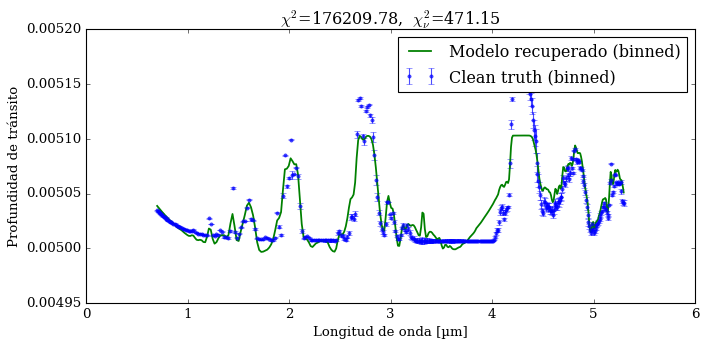

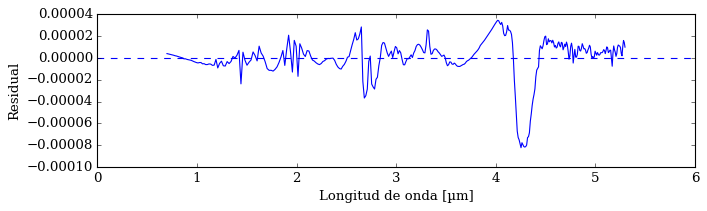

In [104]:
# --- Celda 6 (opcional): Guardar tabla y/o hacer un plot rápido ---
import matplotlib.pyplot as plt

# Guardar CSV con detalles
out_df = pd.DataFrame({
    "wl_um": wl_data,
    "half_bin_um": half_bin,
    "clean_binned": clean_binned,
    "model_binned": model_binned,
    "err_obs": err_obs,
    "residual": resid,
    "chi2_contrib": (resid/err_obs)**2
})
out_df.to_csv("chi2_vs_clean_table.csv", index=False)
print("Guardado: chi2_vs_clean_table.csv")

# Plot opcional (visual rápido)
plt.figure(figsize=(9,4.5))
plt.errorbar(wl_data, clean_binned, yerr=err_obs, fmt='.', alpha=0.7, label="Clean truth (binned)")
plt.plot(wl_data, model_binned, lw=1.6, label="Modelo recuperado (binned)")
plt.xlabel("Longitud de onda [µm]")
plt.ylabel("Profundidad de tránsito")
plt.title(rf"$\chi^2$={chi2:.2f},  $\chi^2_\nu$={chi2red:.2f}")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,2.8))
plt.axhline(0, ls="--")
plt.plot(wl_data, resid, lw=1.0)
plt.xlabel("Longitud de onda [µm]")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()
